# Uncertainty and sentiment in annual and quarterly reports

FRE-GY 7871 A · Assignment 1 · Filing dates: January 2021 through September 9, 2026

This notebook computes dictionary-based negative sentiment and uncertainty,
constructs filing-event outcomes and controls, and presents six tables and one
figure. The course-period comparison covers January 2021 through December 2025.
Negative sentiment and uncertainty are analysed separately. The company
universe is derived from the supplied ARK holdings and resolved to SEC filers;
actual acquisition and sample counts appear below.

Run all cells after downloading the complete local filing corpus, lexicons,
prices, corporate actions and filing-specific share counts. The computation
requires local data excluded from the repository. Tables and the figure are
recomputed when the notebook runs. Saved outputs are aggregate results; the
notebook does not embed filing documents or the observation-level dataset.


In [1]:
from pathlib import Path
import sys
import json
import io
from contextlib import redirect_stdout
from collections import Counter

import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image, HTML

# Execution from the repository or its immediate project directory is supported.
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'analysis.py').is_file():
    if (ROOT / 'assignment' / 'src' / 'analysis.py').is_file():
        ROOT = ROOT / 'assignment'
    else:
        raise RuntimeError('Open this notebook with the assignment repository as the working directory.')
sys.path.insert(0, str(ROOT))
from src.analysis import run_analysis
from src.scoring import score_corpus
from src.config import OUTPUT_DIR, SAMPLE_START, SAMPLE_END, AS_OF_DATE
from src.report_math import format_number
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


## Tone measures

For dictionary category $c$, the proportional score is

$$P_{cj}=\frac{\sum_{i\in c}tf_{ij}}{W_j}.$$

Here $W_j$ is the number of tokens in filing $j$. Percentages in descriptive tables equal $100P_{cj}$; regressions
use the fraction in its original units.

The equation (1) weighted score is

$$T_{cj}=\sum_{i\in c:tf_{ij}>0}
\frac{1+\ln(tf_{ij})}{1+\ln(a_j)}\ln\left(\frac{N}{df_i}\right),
\qquad a_j=\frac{W_j}{V_j}.$$

Here $V_j$ is the number of distinct words in filing $j$, $N$ is the number
of documents in the estimation corpus and $df_i$ is document frequency.
All logarithms are natural. The weighted score is a sum, not a proportion.
Document frequencies are fitted independently for the text, volatility and
return samples and refitted within annual-report and quarterly-report samples.
The active categories in the 1993–2025 Master Dictionary (updated March 2026)
contain 2,345 negative words and 297 uncertainty words. Positive category years
identify active entries; negative years mark removals and are excluded.
[Official dictionary and documentation](https://sraf.nd.edu/loughranmcdonald-master-dictionary/).

The three constructed documents below provide a worked example of the formula.


In [2]:
example_documents = [Counter('LOSS LOSS RISK GAIN'.split()),
                     Counter('LOSS GAIN GAIN'.split()),
                     Counter('RISK RISK RISK GAIN'.split())]
equation_example = score_corpus(example_documents, {'Example': {'LOSS', 'RISK'}})
equation_example.index = ['d1', 'd2', 'd3']
equation_example['a_j'] = equation_example.n_words / equation_example.n_distinct
np.testing.assert_allclose(equation_example.Example_tfidf, [0.8480, 0.2885, 0.5026], atol=0.00005)
display(equation_example[['a_j', 'Example_prop', 'Example_tfidf']].style.format('{:.4f}'))


,a_j,Example_prop,Example_tfidf
d1,1.3333,0.7500,0.8480
d2,1.5000,0.3333,0.2885
d3,2.0000,0.7500,0.5026


## Sample and event construction

Filters remove amendments and failed parses; require at least 2,000 words for
10-Ks or 1,000 for 10-Qs; and retain the earliest filing per company and
calendar quarter. These filters define the text sample for descriptive statistics
and trends. Outcome samples additionally require a usable event date, a preceding
close of at least \$3, sufficient price history, the relevant complete outcome
window, and filing-specific shares and controls. Table 1 reports separate text,
volatility and return sample waterfalls. Recent filings remain in text analysis
even when future return or volatility windows have not yet completed.

Acceptance timestamps are converted from UTC to Eastern time. Acceptance at or
after the NYSE session’s actual closing time, including an early close, shifts
its calendar date forward one day. Day 0 is the first NYSE trading day on or
after the later of this date and the filing date.

Total-return adjusted closes measure buy-and-hold excess returns against SPY
for days [0,+3], starting from the close on day −1. Realised volatility uses
returns over [−60,−6] before filing and [+4,+63] after filing, annualised by
$\sqrt{252}$. Market observations end with the last completed session before the analysis
cutoff. Missing future returns are not imputed. The final 2026 quarter is
incomplete; its filing counts and quarterly averages cover only the elapsed
portion of the quarter.

Historical nominal closes determine the \$3 filter and size. Share counts must
match the scored accession and use a valid cover-page instant no later than
filing; weighted-average shares are not a substitute. Historical nominal
volume times nominal close gives dollar volume. Corporate actions are retained
to undo subsequent splits in Yahoo's split-adjusted price and volume histories.


In [3]:
# This call checks acquisition completeness before constructing the sample.
# Its detailed progress text is suppressed; aggregate counts are displayed below.
with redirect_stdout(io.StringIO()):
    analysis_sample = run_analysis()
    course_sample = run_analysis(sample_end='2025-12-31', output_dir=OUTPUT_DIR / 'course_2021_2025')
audit = json.loads((OUTPUT_DIR / 'audit.json').read_text())
print(f"Filing dates: {audit['sample_start']} to {audit['sample_end']}; market observations through {audit['market_last_date']}.")
print(f"Text sample: {audit['final_filings']:,} filings from {audit['final_companies']:,} companies.")
print(f"Volatility sample: {audit['volatility_filings']:,}; return sample: {audit['return_filings']:,} filings.")
print(f"All scored original filings: {audit['all_scored_filings']:,}.")
print(f"Day-0 shifts before market filters: {audit['day0_moved_before_market_filters']:,}.")

print('Dictionary word counts:', audit['lexicon_counts'])
print('Words shared by the two dictionaries:', audit['lexicon_overlap'])

def show_table(number):
    table = pd.read_csv(OUTPUT_DIR / f'table{number}.csv')
    display(HTML(table.map(lambda value: format_number(value, digits=5, target='html')).to_html(index=False, escape=False)))
    return table


Filing dates: 2021-01-01 to 2026-09-09; market observations through 2026-09-08.
Text sample: 1,935 filings from 97 companies.
Volatility sample: 1,600; return sample: 1,682 filings.
All scored original filings: 1,943.
Day-0 shifts before market filters: 1,099.
Dictionary word counts: {'Negative': 2345, 'Uncertainty': 297}
Words shared by the two dictionaries: 40


## Table 1. Sample filters

Removal counts follow the stated order; additional complete-case restrictions are shown explicitly.

In [4]:
display(pd.read_csv(OUTPUT_DIR / 'table1_universe.csv'))
table1 = show_table(1)

,filter,removed,remaining,unit
0,Raw holding identifiers,0,130,identifiers
1,Funds and non-company securities,4,126,identifiers
2,Foreign local listings,8,118,identifiers
3,Unresolved SEC identifiers,3,115,identifiers
4,Combine share classes by company CIK,1,114,companies
5,foreign_reporting_forms,17,97,companies


sample,filter,removed,remaining,companies
Text,All 10-K/Q and amendments,0,"2,001",97
Text,Remove amendments and parse failures,58,"1,943",97
Text,"Minimum words: 2,000 K / 1,000 Q",0,"1,943",97
Text,Earliest company filing each quarter,8,"1,935",97
Volatility,Eligible text filings,0,"1,935",97
Volatility,Usable day 0 and prior price at least $3,117,"1,818",97
Volatility,Outcome window elapsed by market cutoff,94,"1,724",94
Volatility,60 observed returns before and after,26,"1,698",91
Volatility,Complete pre/post volatility windows,0,"1,698",91
Volatility,Accession-matched outstanding shares,81,"1,617",87


## Table 2. Tone by report type

Proportional scores are percentages. Weighted scores are in equation (1) units. Annual and quarterly reports are reported separately.

In [5]:
table2 = show_table(2)

form,measure,n,mean,sd,p25,median,p75,min,max
10-K,Negative words (%),489,2.29828,0.42027,2.01339,2.31017,2.58093,0.98244,3.35197
10-K,Uncertainty words (%),489,1.96255,0.24151,1.82124,1.97879,2.13164,1.21396,2.51398
10-K,Negative tf.idf,489,100.78406,36.89793,71.61904,93.65922,128.69716,30.87521,207.91284
10-K,Uncertainty tf.idf,489,15.86803,5.66627,11.95819,15.01001,18.94324,3.76820,38.48182
10-Q,Negative words (%),"1,446",2.04907,0.97162,1.17731,1.80907,2.98285,0.20982,5.13031
10-Q,Uncertainty words (%),"1,446",1.81964,0.58701,1.32092,1.65188,2.41520,0.74746,3.25979
10-Q,Negative tf.idf,"1,446",93.05668,79.23750,26.66493,59.41117,156.31396,2.10425,322.10153
10-Q,Uncertainty tf.idf,"1,446",15.95105,8.62055,8.95176,13.98947,22.34650,2.67264,45.94401


## Table 3. Frequent dictionary words

Counts pool the text sample. Each share is the word's count divided by all observed tokens in its dictionary category.

In [6]:
table3 = show_table(3)
print('Top-ten shares of category tokens (%):', audit['top10_shares'])

category,rank,word,count,share_pct
Negative,1,LOSS,"92,353",5.16961
Negative,2,ADVERSELY,"75,026",4.19971
Negative,3,LOSSES,"55,461",3.10452
Negative,4,CLAIMS,"55,122",3.08555
Negative,5,ADVERSE,"50,275",2.81423
Negative,6,AGAINST,"44,064",2.46656
Negative,7,UNABLE,"36,088",2.02009
Negative,8,LITIGATION,"35,626",1.99423
Negative,9,HARM,"33,998",1.90310
Negative,10,FAILURE,"32,964",1.84522


Top-ten shares of category tokens (%): {'Negative': 28.602799506061714, 'Uncertainty': 74.85883693745181}


## Negative sentiment and uncertainty correlations

Pearson correlations are reported for proportional and weighted scores in the full sample and by report type. Weighted scores are refitted within each reported sample.

In [7]:
display(HTML(pd.DataFrame(audit['correlations']).map(lambda value: format_number(value, digits=4, target='html')).to_html(index=False, escape=False)))

form,prop,tfidf
All,0.8485,0.9173
10-K,0.7204,0.8225
10-Q,0.8539,0.9230


## Filing example

The example selects the largest difference between the negative-tone and uncertainty percentile ranks. This is a descriptive contrast, not a randomly selected or representative report.

In [8]:
example = audit['example']
display(Markdown(f"**{example['ticker']} · {example['form']} · {example['filing_date']}**"))
print(f"Negative words: {example['negative_pct']:.3f}%; uncertainty words: {example['uncertainty_pct']:.3f}%.")
print(f"Percentile ranks: negative {100*example['negative_percentile']:.1f}, uncertainty {100*example['uncertainty_percentile']:.1f}.")
display(Markdown('> ' + example['sentence'].replace('\n', ' ')))
display(Markdown(f"[SEC filing]({example['doc_url']}) · Accession {example['accession']}"))


**TSLA · 10-Q · 2023-10-23**

Negative words: 2.722%; uncertainty words: 1.047%.
Percentile ranks: negative 71.2, uncertainty 4.1.


> On October 27, 2021, the Court approved the parties’ joint stipulation that, among other things, (a) all claims against Kimbal Musk and Steve Jurvetson …

[SEC filing](https://www.sec.gov/Archives/edgar/data/1318605/000162828023034847/tsla-20230930.htm) · Accession 0001628280-23-034847

## Trend specifications

For each tone measure, quarter-level means estimate

$$\bar T_q=\alpha+\beta\tau_q+\sum_{s=2}^4\delta_sD_{sq}+\varepsilon_q.$$

Time $\tau_q$ is elapsed years from the first sample quarter; $\beta$ is annual change.
Ordinary OLS inference and heteroskedasticity/autocorrelation-consistent
inference with four quarterly lags are both reported.

The filing-level model is

$$T_{iq}=\alpha_i+\beta\tau_q+\sum_{s=2}^4\delta_sD_{sq}
+\theta K_{iq}+\varepsilon_{iq},$$

where $\alpha_i$ is a firm effect and $K$ is a 10-K indicator. This model
controls company mean levels and report type; entry and exit selection may remain. A saturated calendar-quarter effect
would absorb the linear trend and is therefore excluded. The 10-K indicator
is omitted in samples containing only one report type.

Firm-clustered and two-way firm/calendar-quarter clustered inference are
reported. Two-way p-values and intervals use $\min(G_{firm},G_{quarter})-1$
degrees of freedom. Non-estimable or nonpositive-variance cases are labelled
rather than assigned a p-value.


## Table 4. Tone trends

The same specifications are estimated for the full sample, 10-Ks and 10-Qs. Separate report-type samples refit weighted scores on their own documents.

In [9]:
table4 = show_table(4)

model,outcome,term,inference,n,firm_clusters,quarter_clusters,coef,se,t,p,ci_low,ci_high,mde80,df_inference,r_squared,controls,fixed_effects,form_control,dropped_nuisance,design_rank,status,measure,sample
aggregate_trend,Negative_prop,time_years,OLS,23,0,23,2.10 × 10-4,7.53 × 10-5,2.78995,0.01209,5.19 × 10-5,3.68 × 10-4,2.21 × 10-4,18,0.79819,"time_years,season2,season3,season4",—,False,—,5,ok,Negative_prop,All
aggregate_trend,Negative_prop,time_years,HAC4,23,0,23,2.10 × 10-4,9.00 × 10-5,2.33421,0.03137,2.10 × 10-5,3.99 × 10-4,2.65 × 10-4,18,0.79819,"time_years,season2,season3,season4",—,False,—,5,ok,Negative_prop,All
within_firm_trend,Negative_prop,time_years,firm_cluster,"1,935",97,23,1.00 × 10-4,1.15 × 10-4,0.87380,0.38441,-1.28 × 10-4,3.29 × 10-4,3.25 × 10-4,96,0.71831,"time_years,season2,season3,season4",cik,True,—,102,ok,Negative_prop,All
within_firm_trend,Negative_prop,time_years,firm_quarter_cluster,"1,935",97,23,1.00 × 10-4,1.17 × 10-4,0.85603,0.40121,-1.43 × 10-4,3.44 × 10-4,3.42 × 10-4,22,0.71831,"time_years,season2,season3,season4",cik,True,—,102,ok,Negative_prop,All
aggregate_trend,Uncertainty_prop,time_years,OLS,23,0,23,3.29 × 10-5,4.78 × 10-5,0.68867,0.49981,-6.75 × 10-5,1.33 × 10-4,1.41 × 10-4,18,0.74418,"time_years,season2,season3,season4",—,False,—,5,ok,Uncertainty_prop,All
aggregate_trend,Uncertainty_prop,time_years,HAC4,23,0,23,3.29 × 10-5,5.53 × 10-5,0.59518,0.55913,-8.33 × 10-5,1.49 × 10-4,1.63 × 10-4,18,0.74418,"time_years,season2,season3,season4",—,False,—,5,ok,Uncertainty_prop,All
within_firm_trend,Uncertainty_prop,time_years,firm_cluster,"1,935",97,23,-3.75 × 10-5,7.43 × 10-5,-0.50419,0.61528,-1.85 × 10-4,1.10 × 10-4,2.10 × 10-4,96,0.67549,"time_years,season2,season3,season4",cik,True,—,102,ok,Uncertainty_prop,All
within_firm_trend,Uncertainty_prop,time_years,firm_quarter_cluster,"1,935",97,23,-3.75 × 10-5,7.27 × 10-5,-0.51511,0.61161,-1.88 × 10-4,1.13 × 10-4,2.12 × 10-4,22,0.67549,"time_years,season2,season3,season4",cik,True,—,102,ok,Uncertainty_prop,All
aggregate_trend,Negative_tfidf,time_years,OLS,23,0,23,1.55091,0.61355,2.52777,0.02105,0.26189,2.83993,1.80540,18,0.98324,"time_years,season2,season3,season4",—,False,—,5,ok,Negative_tfidf,All
aggregate_trend,Negative_tfidf,time_years,HAC4,23,0,23,1.55091,0.77622,1.99805,0.06105,-0.07985,3.18168,2.28405,18,0.98324,"time_years,season2,season3,season4",—,False,—,5,ok,Negative_tfidf,All


## Figure 1. Quarterly tone and VIX

Report types are shown separately with within-form tf.idf. Company-centered means reduce baseline composition differences, but entry/exit timing can still affect this unbalanced panel. Formal inference relies on Table 4. Gray dashed lines show quarterly VIX on the right axes. The latest quarter is partial. Annual-report quarterly counts can be very small and are shown below.

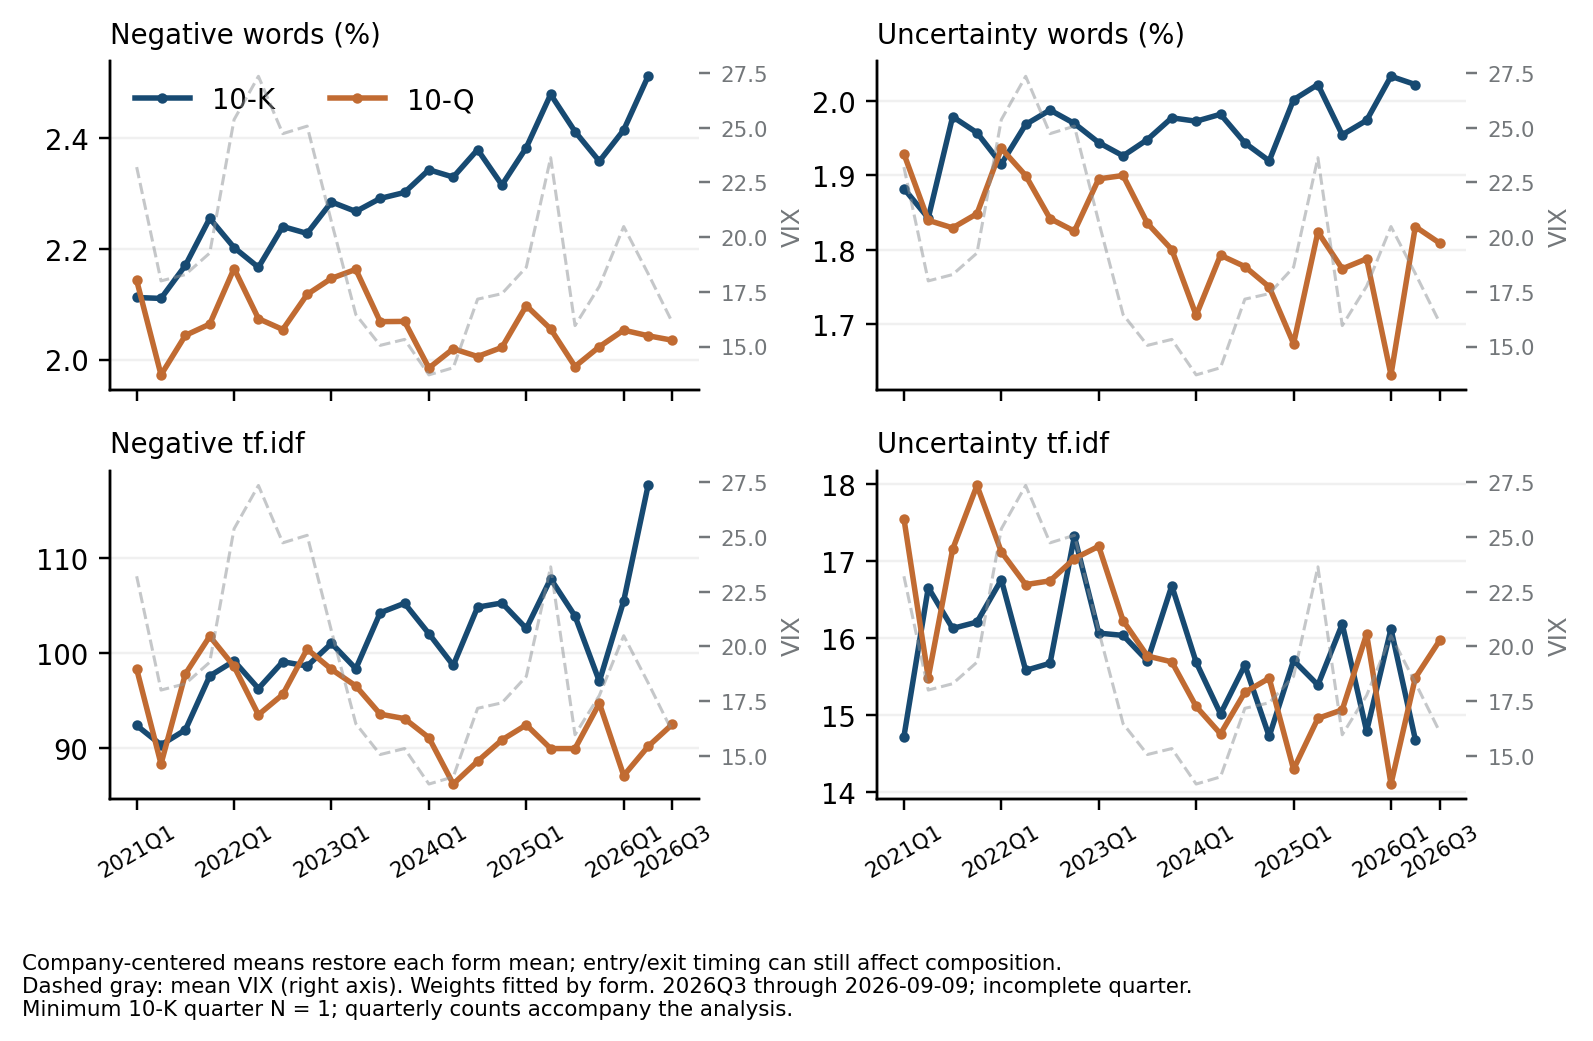

form,10-K,10-Q
quarter,,
2021Q1,61,7
2021Q2,1,73
2021Q3,1,76
2021Q4,7,73
2022Q1,69,8
2022Q2,4,78
2022Q3,1,81
2022Q4,7,76
2023Q1,73,9


In [10]:
display(Image(filename=str(OUTPUT_DIR / 'figure1.png')))
display(pd.DataFrame(audit['quarter_counts']).pivot(index='quarter', columns='form', values='n').fillna(0).astype(int))

## Outcome specifications

Define the common controls as

$$\begin{aligned}
C_{iq}={}&\gamma_1\ln(\mathrm{Size}_{iq})+\gamma_2\ln(\mathrm{DollarVolume}_{iq})\\
&+\gamma_3R^{\mathrm{pre,excess}}_{iq}+\theta K_{iq}.
\end{aligned}$$

For uncertainty $U$, the volatility model is

$$\sigma^{\mathrm{post}}_{iq}=\alpha_i+\lambda_q+\beta U_{iq}
+C_{iq}+[\rho\sigma^{\mathrm{pre}}_{iq}]+\varepsilon_{iq}.$$

Both proportional and weighted uncertainty are estimated with and without
the bracketed pre-filing volatility control, using exactly the same complete
observations within each comparison. $\lambda_q$ is a calendar-quarter effect.
Dollar volume and prior excess return use [−60,−6]; size uses the day −1 price
and shares printed on the scored filing.

For negative sentiment $N$, the filing-return model is

$$R^{[0,3],\mathrm{excess}}_{iq}=\alpha_i+\lambda_q+\beta N_{iq}
+C_{iq}+\rho\sigma^{\mathrm{pre}}_{iq}+\varepsilon_{iq}.$$

Both tone versions use firm and quarter effects, all listed controls, and the
same two clustering alternatives. No winsorisation is applied. Coefficients
are per one unit of the original score. One-standard-deviation effects aid
comparison. The approximate 80% minimum detectable effect for a two-sided 5% test,
expressed in return percentage points per one tone standard deviation, is

$$\mathrm{MDE}^{\mathrm{pp}}_{80,1\mathrm{SD}}
=100\left(t_{0.975,\nu}+\Phi^{-1}(0.8)\right)
\mathrm{SE}(\hat\beta)\,s_{\mathrm{tone}}.$$

Here $\nu$ is the inference degrees of freedom. Statistical insignificance does not establish
that the association is zero, and these associations are not causal effects.


## Table 5. Uncertainty and post-filing volatility

In [11]:
table5 = show_table(5)

model,outcome,term,inference,n,firm_clusters,quarter_clusters,coef,se,t,p,ci_low,ci_high,mde80,df_inference,r_squared,controls,fixed_effects,form_control,dropped_nuisance,design_rank,status,measure,sample,tone_sd,effect_1sd,mde80_1sd
volatility_without_prevol,post_vol,Uncertainty_prop,firm_cluster,"1,600",87,22,0.46310,1.38532,0.33429,0.73897,-2.29082,3.21702,3.91983,86,0.68463,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess","cik,quarter",True,—,113,ok,Uncertainty_prop,All,0.00517,0.00239,0.02026
volatility_without_prevol,post_vol,Uncertainty_prop,firm_quarter_cluster,"1,600",87,22,0.46310,1.28471,0.36047,0.72209,-2.20860,3.13480,3.75294,21,0.68463,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess","cik,quarter",True,—,113,ok,Uncertainty_prop,All,0.00517,0.00239,0.01940
volatility_with_prevol,post_vol,Uncertainty_prop,firm_cluster,"1,600",87,22,-0.09635,1.20790,-0.07976,0.93661,-2.49758,2.30489,3.41783,86,0.69612,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,114,ok,Uncertainty_prop,All,0.00517,-4.98 × 10-4,0.01767
volatility_with_prevol,post_vol,Uncertainty_prop,firm_quarter_cluster,"1,600",87,22,-0.09635,1.06307,-0.09063,0.92865,-2.30711,2.11442,3.10547,21,0.69612,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,114,ok,Uncertainty_prop,All,0.00517,-4.98 × 10-4,0.01605
volatility_without_prevol,post_vol,Uncertainty_tfidf,firm_cluster,"1,600",87,22,-2.38 × 10-5,0.00102,-0.02322,0.98153,-0.00206,0.00201,0.00290,86,0.68461,"Uncertainty_tfidf,log_size,log_dollar_volume,pre_excess","cik,quarter",True,—,113,ok,Uncertainty_tfidf,All,9.56759,-2.27 × 10-4,0.02771
volatility_without_prevol,post_vol,Uncertainty_tfidf,firm_quarter_cluster,"1,600",87,22,-2.38 × 10-5,0.00112,-0.02125,0.98325,-0.00235,0.00230,0.00327,21,0.68461,"Uncertainty_tfidf,log_size,log_dollar_volume,pre_excess","cik,quarter",True,—,113,ok,Uncertainty_tfidf,All,9.56759,-2.27 × 10-4,0.03126
volatility_with_prevol,post_vol,Uncertainty_tfidf,firm_cluster,"1,600",87,22,-3.15 × 10-4,9.09 × 10-4,-0.34648,0.72983,-0.00212,0.00149,0.00257,86,0.69614,"Uncertainty_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,114,ok,Uncertainty_tfidf,All,9.56759,-0.00301,0.02460
volatility_with_prevol,post_vol,Uncertainty_tfidf,firm_quarter_cluster,"1,600",87,22,-3.15 × 10-4,9.62 × 10-4,-0.32718,0.74677,-0.00232,0.00169,0.00281,21,0.69614,"Uncertainty_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,114,ok,Uncertainty_tfidf,All,9.56759,-0.00301,0.02689
volatility_without_prevol,post_vol,Uncertainty_prop,firm_cluster,423,86,21,-19.32608,17.19288,-1.12407,0.26415,-53.51014,14.85797,48.65395,85,0.75795,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess","cik,quarter",False,cik_0000896878,109,ok,Uncertainty_prop,10-K,0.00245,-0.04736,0.11922
volatility_without_prevol,post_vol,Uncertainty_prop,firm_quarter_cluster,423,86,21,-19.32608,16.03113,-1.20553,0.24207,-52.76643,14.11427,46.93249,20,0.75795,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess","cik,quarter",False,cik_0000896878,109,ok,Uncertainty_prop,10-K,0.00245,-0.04736,0.11500


## Table 6. Negative sentiment and filing-period excess return

In [12]:
table6 = show_table(6)

model,outcome,term,inference,n,firm_clusters,quarter_clusters,coef,se,t,p,ci_low,ci_high,mde80,df_inference,r_squared,controls,fixed_effects,form_control,dropped_nuisance,design_rank,status,measure,sample,tone_sd,effect_1sd,mde80_1sd
filing_return,event_excess,Negative_prop,firm_cluster,"1,682",91,23,-0.57653,0.62140,-0.92779,0.35600,-1.81105,0.65800,1.75751,90,0.08828,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,119,ok,Negative_prop,All,0.00862,-0.00497,0.01514
filing_return,event_excess,Negative_prop,firm_quarter_cluster,"1,682",91,23,-0.57653,0.60659,-0.95044,0.35221,-1.83452,0.68146,1.76851,22,0.08828,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,119,ok,Negative_prop,All,0.00862,-0.00497,0.01524
filing_return,event_excess,Negative_tfidf,firm_cluster,"1,682",91,23,-9.91 × 10-5,7.74 × 10-5,-1.28122,0.20341,-2.53 × 10-4,5.46 × 10-5,2.19 × 10-4,90,0.08868,"Negative_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,119,ok,Negative_tfidf,All,73.82028,-0.00732,0.01615
filing_return,event_excess,Negative_tfidf,firm_quarter_cluster,"1,682",91,23,-9.91 × 10-5,8.83 × 10-5,-1.12260,0.27371,-2.82 × 10-4,8.40 × 10-5,2.57 × 10-4,22,0.08868,"Negative_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,119,ok,Negative_tfidf,All,73.82028,-0.00732,0.01900
filing_return,event_excess,Negative_prop,firm_cluster,424,86,22,-3.71195,6.22482,-0.59631,0.55255,-16.08857,8.66467,17.61556,85,0.27450,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,cik_0000896878,111,ok,Negative_prop,10-K,0.00409,-0.01518,0.07205
filing_return,event_excess,Negative_prop,firm_quarter_cluster,424,86,22,-3.71195,7.33612,-0.50598,0.61814,-18.96825,11.54435,21.43054,21,0.27450,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,cik_0000896878,111,ok,Negative_prop,10-K,0.00409,-0.01518,0.08766
filing_return,event_excess,Negative_tfidf,firm_cluster,424,86,22,-8.31 × 10-4,7.08 × 10-4,-1.17360,0.24383,-0.00224,5.77 × 10-4,0.00200,85,0.27674,"Negative_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,cik_0000896878,111,ok,Negative_tfidf,10-K,38.10828,-0.03166,0.07634
filing_return,event_excess,Negative_tfidf,firm_quarter_cluster,424,86,22,-8.31 × 10-4,5.75 × 10-4,-1.44481,0.16327,-0.00203,3.65 × 10-4,0.00168,21,0.27674,"Negative_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,cik_0000896878,111,ok,Negative_tfidf,10-K,38.10828,-0.03166,0.06401
filing_return,event_excess,Negative_prop,firm_cluster,"1,258",90,23,-1.58588,0.86567,-1.83197,0.07030,-3.30594,0.13419,2.44863,89,0.11889,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,—,117,ok,Negative_prop,10-Q,0.00960,-0.01523,0.02351
filing_return,event_excess,Negative_prop,firm_quarter_cluster,"1,258",90,23,-1.58588,1.14475,-1.38535,0.17983,-3.95994,0.78819,3.33751,22,0.11889,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,—,117,ok,Negative_prop,10-Q,0.00960,-0.01523,0.03205


## Course-period comparison: 2021–2025

The requested course window is retained alongside the expanded filing window.
Both periods use the same current active dictionary and sample definitions.
The comparison therefore separates the date coverage from dictionary choices.
[Course-period report](COURSE_REPORT.md) · [Course-period PDF](outputs/course_2021_2025/report.pdf).


In [13]:
course_audit = json.loads((OUTPUT_DIR / 'course_2021_2025' / 'audit.json').read_text())
comparison = pd.DataFrame([
    {'Filing period': 'Expanded', 'Start': audit['sample_start'], 'End': audit['sample_end'],
     'Text filings': audit['final_filings'], 'Volatility filings': audit['volatility_filings'], 'Return filings': audit['return_filings']},
    {'Filing period': 'Course', 'Start': course_audit['sample_start'], 'End': course_audit['sample_end'],
     'Text filings': course_audit['final_filings'], 'Volatility filings': course_audit['volatility_filings'], 'Return filings': course_audit['return_filings']}
])
display(comparison)


,Filing period,Start,End,Text filings,Volatility filings,Return filings
0,Expanded,2021-01-01,2026-09-09,1935,1600,1682
1,Course,2021-01-01,2025-12-31,1655,1437,1437


## AI assistance

OpenAI Codex generated analysis code, tests and notebook text and assisted with
data acquisition and execution. Numerical outputs are produced by running the
analysis on the acquired corpus; they are not supplied as invented examples.
This statement does not imply that the student independently wrote or reviewed
the generated code. The accompanying AI-use disclosure records the assistance.
